In [1]:
import os, random, gc, itertools, json
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

In [2]:
DATASET_DIR   = '/kaggle/input/datasets/almiraraisa/aptos-2019-224px-aug-v2'
device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES   = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
NUM_CLASSES   = len(CLASS_NAMES)
CKPT_DIR      = '/kaggle/working'
os.makedirs(CKPT_DIR, exist_ok=True)

NUM_EPOCHS    = 100
SEARCH_SEED   = 33
SEARCH_EPOCHS = 40

ARCH_SEARCH = {
    'lr'          : [1e-3, 5e-4, 1e-4, 5e-5],
    'weight_decay': [1e-4, 1e-5, 1e-6],
    'batch_size'  : [16, 32, 64],
    'dropout'     : [0.2, 0.3, 0.4, 0.5],
}
DISTILL_SEARCH = {
    'temperature': [3, 5, 7, 10],
    'alpha'      : [0.3, 0.5, 0.7, 0.9],
}
BETA_SEARCH = [0.5, 1.0, 2.0]

In [3]:
def save_phase_results(phase_name, results):
    path = f'{CKPT_DIR}/phase_{phase_name}.json'
    with open(path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"  [checkpoint] Phase '{phase_name}' results saved → {path}")

def load_phase_results(phase_name):
    path = f'{CKPT_DIR}/phase_{phase_name}.json'
    if os.path.exists(path):
        with open(path, 'r') as f:
            results = json.load(f)
        print(f"  [checkpoint] Phase '{phase_name}' already done — loaded from {path}")
        return results
    return None

def phase_is_done(phase_name):
    return os.path.exists(f'{CKPT_DIR}/phase_{phase_name}.json')

In [4]:
def save_best_weights(path, epoch, model, qwk):
    torch.save({'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'qwk': qwk}, path)

def save_resume_ckpt(path, epoch, model, optimizer, scheduler, scaler,
                     history, best_qwk, best_preds, best_labels):
    torch.save({'epoch':            epoch,
                'model_state_dict': model.state_dict(),
                'optimizer':        optimizer.state_dict(),
                'scheduler':        scheduler.state_dict(),
                'scaler':           scaler.state_dict(),
                'history':          history,
                'best_qwk':         best_qwk,
                'best_preds':       best_preds,
                'best_labels':      best_labels}, path)

def load_resume_ckpt(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    scaler.load_state_dict(ckpt['scaler'])
    print(f"  [checkpoint] Resumed from epoch {ckpt['epoch']+1} "
          f"(best QWK so far: {ckpt['best_qwk']:.4f})")
    return (ckpt['epoch'] + 1, ckpt['history'],
            ckpt['best_qwk'], ckpt['best_preds'], ckpt['best_labels'])

In [5]:
def set_seed(seed=30):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def _compute_mse_rmse(labels, preds):
    la = np.array(labels, dtype=np.float32)
    pa = np.array(preds,  dtype=np.float32)
    mse  = float(np.mean((la - pa) ** 2))
    return mse, float(np.sqrt(mse)), float(np.mean(np.abs(la - pa)))

In [6]:
class AptosDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img_col = 'id_code' if 'id_code' in self.df.columns else self.df.columns[0]
        fname   = str(row[img_col])
        fname   = fname if fname.endswith('.png') else fname + '.png'
        img     = Image.open(self.image_dir / fname).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['diagnosis']), dtype=torch.long)

base_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_df = pd.read_csv(f'{DATASET_DIR}/train_split.csv')
val_df   = pd.read_csv(f'{DATASET_DIR}/val_split.csv')
test_df  = pd.read_csv(f'{DATASET_DIR}/test_split.csv')
train_df['diagnosis'] = train_df['diagnosis'].astype(int)

class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[x]).values

val_loader  = DataLoader(AptosDataset(val_df,  f'{DATASET_DIR}/images', base_tfm),
                         batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(AptosDataset(test_df, f'{DATASET_DIR}/images', base_tfm),
                         batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

def make_train_loader(batch_size):
    return DataLoader(
        AptosDataset(train_df, f'{DATASET_DIR}/images', base_tfm),
        batch_size = batch_size,
        sampler    = WeightedRandomSampler(
            torch.tensor(sample_weights, dtype=torch.float),
            len(sample_weights), replacement=True),
        num_workers=4, pin_memory=True)

In [7]:
class CoralHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc   = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))
    def forward(self, x):
        return self.fc(x) + self.bias

def coral_loss(logits, labels, num_classes=NUM_CLASSES):
    targets = torch.zeros(labels.size(0), num_classes - 1, device=labels.device)
    for k in range(num_classes - 1):
        targets[:, k] = (labels > k).float()
    return F.binary_cross_entropy_with_logits(logits, targets)

def coral_predict(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1).long()

def coral_to_softmax(logits):
    cum   = torch.sigmoid(logits)
    p0    = 1.0 - cum[:, 0:1]
    pmid  = cum[:, :-1] - cum[:, 1:]
    plast = cum[:, -1:]
    return torch.cat([p0, pmid, plast], dim=1).clamp(min=1e-6)

def coral_kd_loss(s_logits, t_logits, labels, alpha, temperature, beta):
    ord_loss     = coral_loss(s_logits, labels)
    s_probs      = coral_to_softmax(s_logits)
    t_soft       = F.softmax(t_logits / temperature, dim=1)
    s_soft       = s_probs ** (1.0 / temperature)
    s_soft       = s_soft / s_soft.sum(dim=1, keepdim=True)
    s_log_t      = torch.log(s_soft + 1e-8)
    kd_loss      = F.kl_div(s_log_t, t_soft, reduction='batchmean') * (temperature ** 2)
    return (1 - alpha) * beta * ord_loss + alpha * kd_loss

def make_mobilenet_ce(dropout):
    m       = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_feat = m.classifier[-1].in_features
    m.classifier[-1] = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_feat, NUM_CLASSES))
    return m

def make_mobilenet_coral(dropout):
    m       = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_feat = m.classifier[-1].in_features
    m.classifier[-1] = nn.Dropout(p=dropout)
    m.coral_head     = CoralHead(in_feat, NUM_CLASSES)
    return m

def get_resnet50_teacher():
    m    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

In [8]:
def train_ce_only_arch_search(lr, weight_decay, batch_size, dropout,
                               num_epochs=SEARCH_EPOCHS):
    loader = make_train_loader(batch_size)
    set_seed(SEARCH_SEED)
    model  = make_mobilenet_ce(dropout).to(device)
    opt    = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    scaler = torch.amp.GradScaler('cuda')
    best_qwk = -1.0
    for epoch in range(num_epochs):
        model.train()
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                loss = F.cross_entropy(model(imgs), labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        model.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        if qwk > best_qwk: best_qwk = qwk
    del model; cleanup_memory()
    return best_qwk

In [9]:
stage0a_results = load_phase_results('stage0a')
if stage0a_results is None:
    print("\n" + "="*65)
    print("  STAGE 0A — LR × Weight Decay  (BS=32, Dropout=0.3 fixed)")
    print("="*65)
    stage0a_results = []
    for lr, wd in itertools.product(ARCH_SEARCH['lr'], ARCH_SEARCH['weight_decay']):
        print(f"  Trial | LR={lr}  WD={wd}", end='  ', flush=True)
        qwk = train_ce_only_arch_search(lr=lr, weight_decay=wd,
                                        batch_size=32, dropout=0.3)
        print(f"→ QWK={qwk:.4f}")
        stage0a_results.append({'lr': lr, 'wd': wd, 'qwk': qwk})
    stage0a_results.sort(key=lambda x: x['qwk'], reverse=True)
    save_phase_results('stage0a', stage0a_results)

best_lr = stage0a_results[0]['lr']
best_wd = stage0a_results[0]['wd']
print(f"\n  Stage 0A best: LR={best_lr}  WD={best_wd}  "
      f"QWK={stage0a_results[0]['qwk']:.4f}")

  [checkpoint] Phase 'stage0a' already done — loaded from /kaggle/working/phase_stage0a.json

  Stage 0A best: LR=0.001  WD=0.0001  QWK=0.9067


In [10]:
stage0b_results = load_phase_results('stage0b')
if stage0b_results is None:
    print("\n" + "="*65)
    print(f"  STAGE 0B — Batch Size × Dropout  (LR={best_lr}, WD={best_wd} fixed)")
    print("="*65)
    stage0b_results = []
    for bs, dr in itertools.product(ARCH_SEARCH['batch_size'], ARCH_SEARCH['dropout']):
        print(f"  Trial | BS={bs}  Dropout={dr}", end='  ', flush=True)
        qwk = train_ce_only_arch_search(lr=best_lr, weight_decay=best_wd,
                                        batch_size=bs, dropout=dr)
        print(f"→ QWK={qwk:.4f}")
        stage0b_results.append({'bs': bs, 'dropout': dr, 'qwk': qwk})
    stage0b_results.sort(key=lambda x: x['qwk'], reverse=True)
    save_phase_results('stage0b', stage0b_results)

best_bs      = stage0b_results[0]['bs']
best_dropout = stage0b_results[0]['dropout']
print(f"\n  Stage 0B best: BS={best_bs}  Dropout={best_dropout}  "
      f"QWK={stage0b_results[0]['qwk']:.4f}")

print("\n" + "="*65)
print("  STAGE 0 COMPLETE — Shared Architecture Config")
print("="*65)
print(f"  LR={best_lr}  WD={best_wd}  BS={best_bs}  Dropout={best_dropout}")

train_loader = make_train_loader(best_bs)

  [checkpoint] Phase 'stage0b' already done — loaded from /kaggle/working/phase_stage0b.json

  Stage 0B best: BS=64  Dropout=0.4  QWK=0.9164

  STAGE 0 COMPLETE — Shared Architecture Config
  LR=0.001  WD=0.0001  BS=64  Dropout=0.4


In [11]:
def train_teacher_ce(model, name, save_path):
    resume_path = save_path.replace('.pth', '_resume.pth')
    model       = model.to(device)
    opt         = optim.AdamW(model.parameters(), lr=best_lr, weight_decay=best_wd)
    sched       = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler      = torch.amp.GradScaler('cuda')
    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                   'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0; best_preds, best_labels = [], []; start_epoch = 0
    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, model, opt, sched, scaler)
    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); epoch_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                loss = F.cross_entropy(model(imgs), labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            epoch_loss += loss.item()
        sched.step()
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        model.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        acc = np.mean(np.array(v_labels) == np.array(v_preds))
        _, rmse, mae = _compute_mse_rmse(v_labels, v_preds)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)
        print(f"  [{name}] Epoch {epoch+1:03d} | Loss={avg_loss:.4f} | "
              f"Acc={acc*100:.2f}% | QWK={qwk:.4f}")
        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(save_path, epoch+1, model, best_qwk)
        save_resume_ckpt(resume_path, epoch, model, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)
    model.load_state_dict(torch.load(save_path, map_location=device,
                                     weights_only=False)['model_state_dict'])
    model.eval()
    print(f"  [{name}] Best val QWK: {best_qwk:.4f}")
    return model, best_qwk

teacher_save = f'{CKPT_DIR}/teacher_resnet50_shared.pth'
set_seed(SEARCH_SEED)
shared_teacher, t_qwk = train_teacher_ce(get_resnet50_teacher(), "Teacher", teacher_save)
teacher_accuracies     = [t_qwk * 100]
cleanup_memory()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s] 


  [checkpoint] Resumed from epoch 100 (best QWK so far: 0.9022)
  [Teacher] Best val QWK: 0.9022


In [12]:
def train_search_ce_kd(alpha, temperature, beta, num_epochs=SEARCH_EPOCHS):
    loader  = train_loader
    set_seed(SEARCH_SEED)
    student = make_mobilenet_ce(best_dropout).to(device)
    t_ref   = shared_teacher.to(device).eval()
    for p in t_ref.parameters(): p.requires_grad_(False)
    opt     = optim.AdamW(student.parameters(), lr=best_lr, weight_decay=best_wd)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    scaler  = torch.amp.GradScaler('cuda')
    best_qwk = -1.0
    for epoch in range(num_epochs):
        student.train()
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                s_logits = student(imgs); t_logits = t_ref(imgs).detach()
                s_log    = F.log_softmax(s_logits / temperature, dim=1)
                p_t      = F.softmax(t_logits / temperature, dim=1)
                kl       = ((p_t * (p_t.log() - s_log)).sum(dim=1) *
                            temperature**2).clamp(max=10.0)
                loss     = ((1 - alpha) * F.cross_entropy(s_logits, labels) +
                            alpha * kl.mean())
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(student(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        if qwk > best_qwk: best_qwk = qwk
    del student; cleanup_memory()
    return best_qwk

In [13]:
def train_search_coral_kd(alpha, temperature, beta, num_epochs=SEARCH_EPOCHS):
    loader  = train_loader
    set_seed(SEARCH_SEED)
    student = make_mobilenet_coral(best_dropout).to(device)
    t_ref   = shared_teacher.to(device).eval()
    for p in t_ref.parameters(): p.requires_grad_(False)
    opt     = optim.AdamW(student.parameters(), lr=best_lr, weight_decay=best_wd)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    scaler  = torch.amp.GradScaler('cuda')
    best_qwk = -1.0
    for epoch in range(num_epochs):
        student.train()
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                feat    = student.classifier(student.features(imgs).mean([2, 3]))
                s_logits = student.coral_head(feat)
                t_logits = t_ref(imgs).detach()
                loss     = coral_kd_loss(s_logits, t_logits, labels,
                                         alpha=alpha, temperature=temperature, beta=beta)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                feat    = student.classifier(student.features(imgs.to(device)).mean([2, 3]))
                logits  = student.coral_head(feat)
                v_preds.extend(coral_predict(logits).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        if qwk > best_qwk: best_qwk = qwk
    del student; cleanup_memory()
    return best_qwk

In [14]:
def hypersearch_kd(train_fn, search_space, phase_name, tag=""):
    # Load full phase results if already done
    existing = load_phase_results(phase_name)
    if existing is not None:
        existing.sort(key=lambda x: x['qwk'], reverse=True)
        print(f"  {tag} best: T={existing[0]['temperature']}  "
              f"α={existing[0]['alpha']}  β={existing[0]['beta']}  "
              f"QWK={existing[0]['qwk']:.4f}")
        return existing

    # Load partial progress if session died mid-phase
    partial_path = f'{CKPT_DIR}/phase_{phase_name}_partial.json'
    completed    = []
    if os.path.exists(partial_path):
        with open(partial_path, 'r') as f:
            completed = json.load(f)
        print(f"  [checkpoint] Partial progress loaded: "
              f"{len(completed)} trials already done for phase '{phase_name}'")

    completed_keys = {(r['temperature'], r['alpha'], r['beta']) for r in completed}

    trials = list(itertools.product(
        search_space['temperature'],
        search_space['alpha'],
        search_space.get('beta', [1.0]),
    ))

    print(f"\n{'='*65}")
    print(f"  {tag}")
    print(f"  {len(trials)} trials total, "
          f"{len(trials) - len(completed_keys)} remaining")
    print(f"{'='*65}")

    results = list(completed)

    for T, alpha, beta in trials:
        if (T, alpha, beta) in completed_keys:
            print(f"  [skip] T={T}  α={alpha}  β={beta}  (already done)")
            continue
        print(f"\n  Trial | T={T}  α={alpha}  β={beta}", end='  ', flush=True)
        qwk = train_fn(alpha=alpha, temperature=T, beta=beta)
        print(f"→ Best Val QWK={qwk:.4f}")
        results.append({'temperature': T, 'alpha': alpha, 'beta': beta, 'qwk': qwk})

        # Save partial progress after every completed trial
        with open(partial_path, 'w') as f:
            json.dump(results, f, indent=2)

    results.sort(key=lambda x: x['qwk'], reverse=True)

    print(f"\n  ── {tag} — All Results ──")
    for r in results:
        marker = " ← BEST" if r == results[0] else ""
        print(f"  T={r['temperature']}  α={r['alpha']}  β={r['beta']}"
              f"  QWK={r['qwk']:.4f}{marker}")

    # Save completed phase results and remove partial file
    save_phase_results(phase_name, results)
    if os.path.exists(partial_path):
        os.remove(partial_path)

    return results

In [15]:
# temperature
t_results = hypersearch_kd(
    train_fn     = train_search_ce_kd,
    search_space = {'temperature': DISTILL_SEARCH['temperature'],
                    'alpha': [0.5], 'beta': [1.0]},
    phase_name   = 'phase1_fix_T',
    tag          = "PHASE 1 — Fix Temperature (CE+KD, α=0.5)",
)
T_fixed = t_results[0]['temperature']
print(f"\n  T_fixed = {T_fixed}")

# alpha
ce_results = hypersearch_kd(
    train_fn     = train_search_ce_kd,
    search_space = {'temperature': [T_fixed],
                    'alpha': DISTILL_SEARCH['alpha'], 'beta': [1.0]},
    phase_name   = 'phase2_ce_alpha',
    tag          = f"PHASE 2 — Tune α for CE+KD  (T={T_fixed})",
)
best_ce = ce_results[0]

# alpha x beta
coral_results = hypersearch_kd(
    train_fn     = train_search_coral_kd,
    search_space = {'temperature': [T_fixed],
                    'alpha': DISTILL_SEARCH['alpha'], 'beta': BETA_SEARCH},
    phase_name   = 'phase3_coral_alpha_beta',
    tag          = f"PHASE 3 — Tune α × β for CORAL+KD  (T={T_fixed})",
)
best_coral = coral_results[0]

print("\n" + "="*65)
print("  ALL SEARCH PHASES COMPLETE")
print("="*65)
print(f"  Shared:    LR={best_lr}  WD={best_wd}  BS={best_bs}  "
      f"Dropout={best_dropout}  T={T_fixed}")
print(f"  CE+KD:     α={best_ce['alpha']}  → QWK={best_ce['qwk']:.4f}")
print(f"  CORAL+KD:  α={best_coral['alpha']}  β={best_coral['beta']}"
      f"  → QWK={best_coral['qwk']:.4f}")

  [checkpoint] Phase 'phase1_fix_T' already done — loaded from /kaggle/working/phase_phase1_fix_T.json
  PHASE 1 — Fix Temperature (CE+KD, α=0.5) best: T=10  α=0.5  β=1.0  QWK=0.9054

  T_fixed = 10
  [checkpoint] Phase 'phase2_ce_alpha' already done — loaded from /kaggle/working/phase_phase2_ce_alpha.json
  PHASE 2 — Tune α for CE+KD  (T=10) best: T=10  α=0.5  β=1.0  QWK=0.9054
  [checkpoint] Phase 'phase3_coral_alpha_beta' already done — loaded from /kaggle/working/phase_phase3_coral_alpha_beta.json
  PHASE 3 — Tune α × β for CORAL+KD  (T=10) best: T=10  α=0.3  β=1.0  QWK=0.8394

  ALL SEARCH PHASES COMPLETE
  Shared:    LR=0.001  WD=0.0001  BS=64  Dropout=0.4  T=10
  CE+KD:     α=0.5  → QWK=0.9054
  CORAL+KD:  α=0.3  β=1.0  → QWK=0.8394


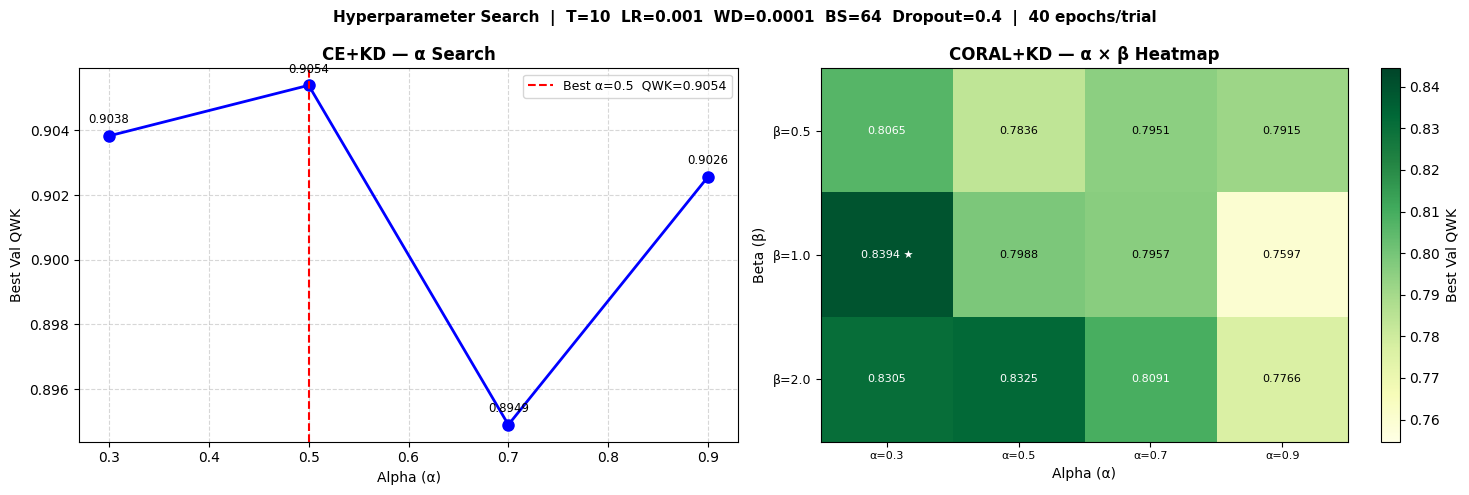

In [16]:
def plot_search_results(ce_results, coral_results, T_fixed):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(
        f"Hyperparameter Search  |  T={T_fixed}  LR={best_lr}  WD={best_wd}  "
        f"BS={best_bs}  Dropout={best_dropout}  |  {SEARCH_EPOCHS} epochs/trial",
        fontsize=11, fontweight='bold')

    ax  = axes[0]
    df  = pd.DataFrame(ce_results).sort_values('alpha')
    ax.plot(df['alpha'], df['qwk'], 'bo-', lw=2, ms=8)
    best_row = df.loc[df['qwk'].idxmax()]
    ax.axvline(best_row['alpha'], color='red', ls='--',
               label=f"Best α={best_row['alpha']}  QWK={best_row['qwk']:.4f}")
    for _, row in df.iterrows():
        ax.annotate(f"{row['qwk']:.4f}", (row['alpha'], row['qwk']),
                    textcoords="offset points", xytext=(0, 9),
                    ha='center', fontsize=8.5)
    ax.set_title("CE+KD — α Search", fontweight='bold')
    ax.set_xlabel("Alpha (α)"); ax.set_ylabel("Best Val QWK")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax  = axes[1]
    df2 = pd.DataFrame(coral_results)
    pivot = df2.pivot_table(index='beta', columns='alpha', values='qwk')
    im    = ax.imshow(pivot.values, cmap='YlGn', aspect='auto',
                      vmin=pivot.values.min() - 0.005,
                      vmax=pivot.values.max() + 0.005)
    plt.colorbar(im, ax=ax, label='Best Val QWK')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"α={v}" for v in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"β={v}" for v in pivot.index], fontsize=9)
    ax.set_title("CORAL+KD — α × β Heatmap", fontweight='bold')
    ax.set_xlabel("Alpha (α)"); ax.set_ylabel("Beta (β)")
    best_coral_row = df2.loc[df2['qwk'].idxmax()]
    for i, b in enumerate(pivot.index):
        for j, a in enumerate(pivot.columns):
            val  = pivot.loc[b, a]
            star = " ★" if (b == best_coral_row['beta'] and
                            a == best_coral_row['alpha']) else ""
            ax.text(j, i, f"{val:.4f}{star}", ha='center', va='center',
                    fontsize=8,
                    color='white' if val > pivot.values.mean() else 'black')

    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/hparam_search_results.png', dpi=130, bbox_inches='tight')
    plt.show()

plot_search_results(ce_results, coral_results, T_fixed)

In [17]:
def is_final_run_done(prefix, seed):
    resume_path = f'{CKPT_DIR}/{prefix}_seed{seed}_resume.pth'
    if not os.path.exists(resume_path):
        return False
    ckpt = torch.load(resume_path, map_location='cpu', weights_only=False)
    return ckpt['epoch'] >= NUM_EPOCHS - 1

def train_final_ce_kd(seed, alpha, temperature):
    prefix      = 'final_ce'
    best_path   = f'{CKPT_DIR}/{prefix}_seed{seed}_best.pth'
    resume_path = f'{CKPT_DIR}/{prefix}_seed{seed}_resume.pth'

    if is_final_run_done(prefix, seed):
        print(f"  [checkpoint] CE+KD seed {seed} already complete — loading best weights")
        student = make_mobilenet_ce(best_dropout).to(device)
        student.load_state_dict(torch.load(best_path, map_location=device,
                                            weights_only=False)['model_state_dict'])
        student.eval()
        ckpt = torch.load(resume_path, map_location='cpu', weights_only=False)
        return {'qwk': ckpt['best_qwk'], 'history': ckpt['history'],
                'preds': ckpt['best_preds'], 'labels': ckpt['best_labels'],
                'seed': seed, 'model': student}

    set_seed(seed)
    student = make_mobilenet_ce(best_dropout).to(device)
    t_ref   = shared_teacher.to(device).eval()
    for p in t_ref.parameters(): p.requires_grad_(False)
    opt     = optim.AdamW(student.parameters(), lr=best_lr, weight_decay=best_wd)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler  = torch.amp.GradScaler('cuda')
    history = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
               'val_mae': [], 'val_rmse': []}
    best_qwk = -1.0; best_preds, best_labels = [], []; start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                s_logits = student(imgs); t_logits = t_ref(imgs).detach()
                s_log    = F.log_softmax(s_logits / temperature, dim=1)
                p_t      = F.softmax(t_logits / temperature, dim=1)
                kl       = ((p_t * (p_t.log() - s_log)).sum(dim=1) *
                            temperature**2).clamp(max=10.0)
                loss     = ((1 - alpha) * F.cross_entropy(s_logits, labels) +
                            alpha * kl.mean())
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()
        sched.step()
        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(student(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        acc = np.mean(np.array(v_labels) == np.array(v_preds))
        _, rmse, mae = _compute_mse_rmse(v_labels, v_preds)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)
        print(f"  [CE-KD s{seed}] Epoch {epoch+1:03d} | Loss={avg_loss:.4f} | "
              f"Acc={acc*100:.2f}% | QWK={qwk:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")
        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(best_path, epoch+1, student, best_qwk)
        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(torch.load(best_path, map_location=device,
                                        weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed, 'model': student}

def train_final_coral_kd(seed, alpha, temperature, beta):
    prefix      = 'final_coral'
    best_path   = f'{CKPT_DIR}/{prefix}_seed{seed}_best.pth'
    resume_path = f'{CKPT_DIR}/{prefix}_seed{seed}_resume.pth'

    if is_final_run_done(prefix, seed):
        print(f"  [checkpoint] CORAL+KD seed {seed} already complete — loading best weights")
        student = make_mobilenet_coral(best_dropout).to(device)
        student.load_state_dict(torch.load(best_path, map_location=device,
                                            weights_only=False)['model_state_dict'])
        student.eval()
        ckpt = torch.load(resume_path, map_location='cpu', weights_only=False)
        return {'qwk': ckpt['best_qwk'], 'history': ckpt['history'],
                'preds': ckpt['best_preds'], 'labels': ckpt['best_labels'],
                'seed': seed, 'model': student}

    set_seed(seed)
    student = make_mobilenet_coral(best_dropout).to(device)
    t_ref   = shared_teacher.to(device).eval()
    for p in t_ref.parameters(): p.requires_grad_(False)
    opt     = optim.AdamW(student.parameters(), lr=best_lr, weight_decay=best_wd)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler  = torch.amp.GradScaler('cuda')
    history = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
               'val_mae': [], 'val_rmse': []}
    best_qwk = -1.0; best_preds, best_labels = [], []; start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), \
                           labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                feat     = student.classifier(student.features(imgs).mean([2, 3]))
                s_logits = student.coral_head(feat)
                t_logits = t_ref(imgs).detach()
                loss     = coral_kd_loss(s_logits, t_logits, labels,
                                         alpha=alpha, temperature=temperature, beta=beta)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()
        sched.step()
        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                feat    = student.classifier(student.features(imgs.to(device)).mean([2, 3]))
                logits  = student.coral_head(feat)
                v_preds.extend(coral_predict(logits).cpu().numpy())
                v_labels.extend(labels.numpy())
        qwk = cohen_kappa_score(np.array(v_labels), np.array(v_preds), weights='quadratic')
        acc = np.mean(np.array(v_labels) == np.array(v_preds))
        _, rmse, mae = _compute_mse_rmse(v_labels, v_preds)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)
        print(f"  [CORAL-KD s{seed}] Epoch {epoch+1:03d} | Loss={avg_loss:.4f} | "
              f"Acc={acc*100:.2f}% | QWK={qwk:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")
        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(best_path, epoch+1, student, best_qwk)
        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(torch.load(best_path, map_location=device,
                                        weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed, 'model': student}

In [18]:
def evaluate_on_test_ce(model, loader):
    model.eval(); t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            t_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds = np.array(t_preds); t_labels = np.array(t_labels)
    qwk = float(cohen_kappa_score(t_labels, t_preds, weights='quadratic'))
    acc = float(np.mean(t_labels == t_preds))
    mse, rmse, mae = _compute_mse_rmse(t_labels, t_preds)
    return {'qwk': qwk, 'acc': acc, 'mse': mse, 'rmse': rmse, 'mae': mae,
            'preds': t_preds.tolist(), 'labels': t_labels.tolist()}

def evaluate_on_test_coral(model, loader):
    model.eval(); t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            feat   = model.classifier(model.features(imgs.to(device)).mean([2, 3]))
            logits = model.coral_head(feat)
            t_preds.extend(coral_predict(logits).cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds = np.array(t_preds); t_labels = np.array(t_labels)
    qwk = float(cohen_kappa_score(t_labels, t_preds, weights='quadratic'))
    acc = float(np.mean(t_labels == t_preds))
    mse, rmse, mae = _compute_mse_rmse(t_labels, t_preds)
    return {'qwk': qwk, 'acc': acc, 'mse': mse, 'rmse': rmse, 'mae': mae,
            'preds': t_preds.tolist(), 'labels': t_labels.tolist()}

In [19]:
print("\n" + "="*65)
print("  FINAL RUNS — seeds [33, 81, 5]")
print(f"  CE+KD:    T={T_fixed}  α={best_ce['alpha']}")
print(f"  CORAL+KD: T={T_fixed}  α={best_coral['alpha']}  β={best_coral['beta']}")
print("="*65)

results_ce_final, results_coral_final   = [], []
students_ce_final, students_coral_final = [], []

for seed in [33, 81, 5]:
    print(f"\n── Seed {seed} — CE+KD ──")
    res = train_final_ce_kd(seed, alpha=best_ce['alpha'], temperature=T_fixed)
    results_ce_final.append(res); students_ce_final.append(res['model'])
    cleanup_memory()

    print(f"\n── Seed {seed} — CORAL+KD ──")
    res = train_final_coral_kd(seed, alpha=best_coral['alpha'],
                                temperature=T_fixed, beta=best_coral['beta'])
    results_coral_final.append(res); students_coral_final.append(res['model'])
    cleanup_memory()


  FINAL RUNS — seeds [33, 81, 5]
  CE+KD:    T=10  α=0.5
  CORAL+KD: T=10  α=0.3  β=1.0

── Seed 33 — CE+KD ──
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 92.1MB/s]


  [checkpoint] Resumed from epoch 13 (best QWK so far: 0.8951)
  [CE-KD s33] Epoch 014 | Loss=0.6110 | Acc=77.60% | QWK=0.8656 | RMSE=0.6714 | MAE=0.2978
  [CE-KD s33] Epoch 015 | Loss=0.5818 | Acc=78.69% | QWK=0.8825 | RMSE=0.6096 | MAE=0.2623
  [CE-KD s33] Epoch 016 | Loss=0.5691 | Acc=77.60% | QWK=0.8668 | RMSE=0.6550 | MAE=0.2869
  [CE-KD s33] Epoch 017 | Loss=0.5689 | Acc=76.50% | QWK=0.8669 | RMSE=0.6855 | MAE=0.3115
  [CE-KD s33] Epoch 018 | Loss=0.5394 | Acc=77.32% | QWK=0.8715 | RMSE=0.6338 | MAE=0.2814
  [CE-KD s33] Epoch 019 | Loss=0.5087 | Acc=80.05% | QWK=0.8598 | RMSE=0.6487 | MAE=0.2678
  [CE-KD s33] Epoch 020 | Loss=0.4892 | Acc=79.23% | QWK=0.8800 | RMSE=0.6273 | MAE=0.2678
  [CE-KD s33] Epoch 021 | Loss=0.4800 | Acc=80.87% | QWK=0.8853 | RMSE=0.6294 | MAE=0.2596
  [CE-KD s33] Epoch 022 | Loss=0.4576 | Acc=78.69% | QWK=0.8903 | RMSE=0.5867 | MAE=0.2568
  [CE-KD s33] Epoch 023 | Loss=0.4413 | Acc=78.96% | QWK=0.8627 | RMSE=0.6653 | MAE=0.2842
  [CE-KD s33] Epoch 024 | L

In [20]:
test_ce_final, test_coral_final = [], []
for seed, m_ce, m_coral in zip([33, 81, 5], students_ce_final, students_coral_final):
    r = evaluate_on_test_ce(m_ce, test_loader);    r['seed'] = seed; test_ce_final.append(r)
    r = evaluate_on_test_coral(m_coral, test_loader); r['seed'] = seed; test_coral_final.append(r)

print("\n" + "="*65)
print("  FINAL TEST RESULTS")
print("="*65)
for label, results in [("CE+KD", test_ce_final), ("CORAL+KD", test_coral_final)]:
    qwks = [r['qwk'] for r in results]; accs = [r['acc']*100 for r in results]
    print(f"\n  {label}")
    print(f"  {'Seed':<6}  {'QWK':>8}  {'Accuracy':>10}  {'RMSE':>8}  {'MAE':>8}")
    print("  " + "-"*46)
    for r in results:
        print(f"  {r['seed']:<6}  {r['qwk']:>8.4f}  {r['acc']*100:>9.2f}%  "
              f"{r['rmse']:>8.4f}  {r['mae']:>8.4f}")
    print("  " + "-"*46)
    print(f"  {'Mean':<6}  {np.mean(qwks):>8.4f}  {np.mean(accs):>9.2f}%  "
          f"{np.mean([r['rmse'] for r in results]):>8.4f}  "
          f"{np.mean([r['mae'] for r in results]):>8.4f}")
    print(f"  {'Std':<6}  {np.std(qwks):>8.4f}  {np.std(accs):>9.2f}%")


  FINAL TEST RESULTS

  CE+KD
  Seed         QWK    Accuracy      RMSE       MAE
  ----------------------------------------------
  33        0.8722      82.56%    0.6329    0.2425
  81        0.8813      81.74%    0.6110    0.2371
  5         0.8745      81.47%    0.6264    0.2452
  ----------------------------------------------
  Mean      0.8760      81.93%    0.6234    0.2416
  Std       0.0039       0.46%

  CORAL+KD
  Seed         QWK    Accuracy      RMSE       MAE
  ----------------------------------------------
  33        0.8705      76.57%    0.6582    0.2916
  81        0.8937      83.92%    0.5789    0.2098
  5         0.8894      82.56%    0.5929    0.2262
  ----------------------------------------------
  Mean      0.8845      81.02%    0.6100    0.2425
  Std       0.0101       3.20%
